#Experiment 8: CNN for Video Classification



Step 1: Import Libraries

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

Step 2: Create Dummy Video Dataset

In [2]:
num_samples = 1000
frames_per_video = 5
img_height, img_width = 64, 64

X = np.random.rand(num_samples, frames_per_video, img_height, img_width, 3)
y = np.random.randint(0, 2, num_samples)

Step 3: Split Dataset

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Step 4: Build CNN Model

In [8]:
model = models.Sequential()

model.add(layers.TimeDistributed(
    layers.Conv2D(32, (3,3), activation='relu'),
    input_shape=(frames_per_video, 64, 64, 3)
))

model.add(layers.TimeDistributed(layers.MaxPooling2D((2,2))))
model.add(layers.TimeDistributed(layers.Conv2D(64, (3,3), activation='relu')))
model.add(layers.TimeDistributed(layers.MaxPooling2D((2,2))))

model.add(layers.TimeDistributed(layers.Flatten()))

# ✅ FIX HERE
model.add(layers.GlobalAveragePooling1D())

model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(2, activation='softmax'))

Step 5: Compile Model

In [9]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Step 6: Train Model

In [10]:
history = model.fit(X_train, y_train, epochs=5,validation_data=(X_test, y_test))

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.5188 - loss: 0.7487 - val_accuracy: 0.5300 - val_loss: 0.6916
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.5263 - loss: 0.6924 - val_accuracy: 0.5300 - val_loss: 0.6915
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.5263 - loss: 0.6932 - val_accuracy: 0.5300 - val_loss: 0.6915
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.5263 - loss: 0.6929 - val_accuracy: 0.5300 - val_loss: 0.6920
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.5263 - loss: 0.6922 - val_accuracy: 0.5300 - val_loss: 0.6917


Step 7: Evaluate Model




In [11]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - accuracy: 0.5300 - loss: 0.6917
Test Accuracy: 0.5299999713897705


Step 8: Plot Accuracy

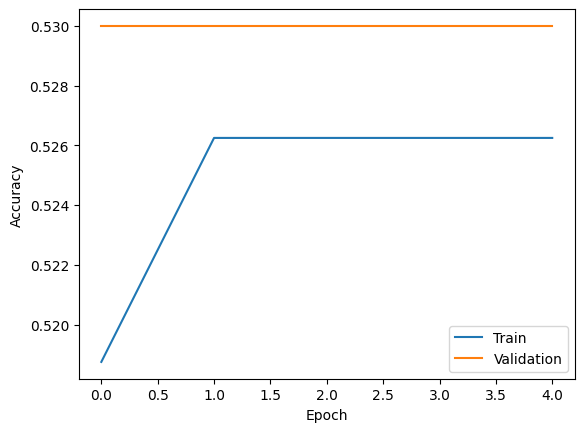

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

___ TESTING ___

In [14]:
index = 0  # change index to test different videos
video = X_test[index]

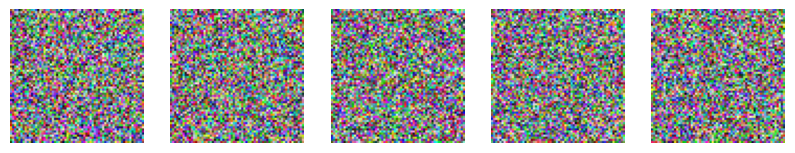

In [15]:
plt.figure(figsize=(10,2))

for i in range(video.shape[0]):
    plt.subplot(1, video.shape[0], i+1)
    plt.imshow(video[i])
    plt.axis('off')

plt.show()

In [16]:
import numpy as np

video = np.expand_dims(video, axis=0)

prediction = model.predict(video)
predicted_class = np.argmax(prediction)

print("Predicted Class:", predicted_class)
print("Actual Class:", y_test[index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
Predicted Class: 0
Actual Class: 0


Test Using Custom “New Video”

In [17]:
new_video = np.random.rand(1, 5, 64, 64, 3)

In [18]:
prediction = model.predict(new_video)
print("Predicted Class:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Class: 0
